# E-commerce Sales Performance Analysis

**Dataset**: Superstore Sales dataset (public practice dataset, 8,399 orders, 21 columns, 2009–2012)

**Goal**: Analyze revenue, profit, and discount patterns to surface actionable business insights.

**Tools**: Python (pandas, matplotlib, seaborn), SQL (SQLite), Excel

## 1. Load and Inspect Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/superstore_sales.csv', encoding='latin1')
df.columns = [c.strip().replace(' ', '_').replace('-','_') for c in df.columns]
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m/%d/%Y')
df['Order_Year'] = df['Order_Date'].dt.year
print('Shape:', df.shape)
df.head()

Shape: (8399, 22)


,Row_ID,Order_ID,Order_Date,Order_Priority,Order_Quantity,Sales,Discount,Ship_Mode,Profit,Unit_Price,...,Province,Region,Customer_Segment,Product_Category,Product_Sub_Category,Product_Name,Product_Container,Product_Base_Margin,Ship_Date,Order_Year
0,1,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010,2010
1,49,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012,2012
2,50,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012,2012
3,80,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011,2011
4,85,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010,2010


In [2]:
# Check for missing values
df.isnull().sum()[df.isnull().sum() > 0]  # only Product_Base_Margin has 63 nulls - minor, ignorable

Product_Base_Margin    63
dtype: int64

## 2. Overall Revenue & Profit

In [3]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
margin = total_profit/total_sales*100
print(f"Total orders: {len(df):,}")
print(f"Total revenue: ${total_sales:,.2f}")
print(f"Total profit: ${total_profit:,.2f}")
print(f"Overall profit margin: {margin:.2f}%")

Total orders: 8,399
Total revenue: $14,915,600.82
Total profit: $1,521,767.98
Overall profit margin: 10.20%


**Finding**: Across 8,399 orders, the business generated **$14.92M** in revenue with **$1.52M** in profit — an overall margin of **10.20%**.

## 3. Revenue by Product Category

Product_Category
Technology         5984248.18
Furniture          5178590.54
Office Supplies    3752762.10
Name: Sales, dtype: float64


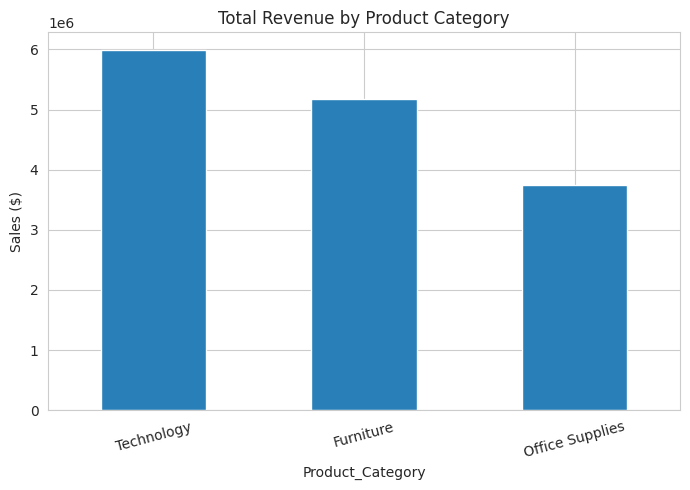

In [4]:
cat_sales = df.groupby('Product_Category')['Sales'].sum().sort_values(ascending=False)
print(cat_sales.round(2))

plt.figure(figsize=(7,5))
cat_sales.plot(kind='bar', color='#2980b9')
plt.title('Total Revenue by Product Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Finding**: **Technology** is the top revenue driver at **$5.98M**, closely followed by **Furniture** (**$5.18M**), with **Office Supplies** trailing at **$3.75M**.

## 4. Yearly Sales Trend

Order_Year
2009    4209139.46
2010    3549680.80
2011    3436816.70
2012    3719963.86
Name: Sales, dtype: float64


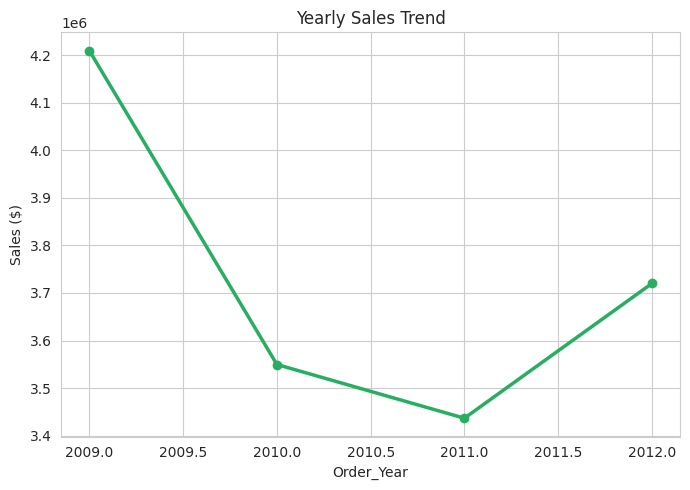

In [5]:
yearly = df.groupby('Order_Year')['Sales'].sum()
print(yearly.round(2))

plt.figure(figsize=(7,5))
yearly.plot(kind='line', marker='o', color='#27ae60', linewidth=2.5)
plt.title('Yearly Sales Trend')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

**Finding**: Sales peaked in **2009 ($4.21M)** then dipped through 2010–2011, recovering slightly in **2012 ($3.72M)**. The overall trend suggests the business hasn't fully returned to its 2009 revenue level.

## 5. Regional Profit Margins

                              Sales     Profit  margin
Region                                                
Northwest Territories  8.008473e+05  100653.08   12.57
Atlantic               2.014248e+06  238960.66   11.86
Ontario                3.063212e+06  346868.54   11.32
Prarie                 2.837305e+06  321160.12   11.32
Quebec                 1.510195e+06  140426.65    9.30
West                   3.597549e+06  297008.61    8.26
Yukon                  9.758674e+05   73849.21    7.57
Nunavut                1.163765e+05    2841.11    2.44


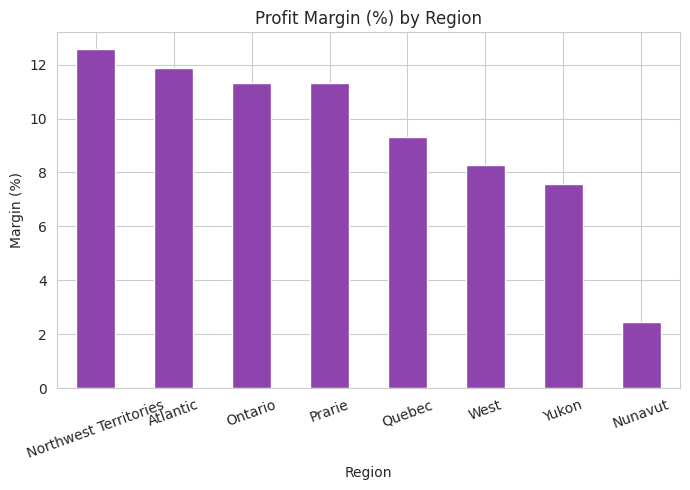

In [6]:
reg = df.groupby('Region').agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
reg['margin'] = (reg['Profit']/reg['Sales']*100).round(2)
reg_sorted = reg.sort_values('margin', ascending=False)
print(reg_sorted)

plt.figure(figsize=(7,5))
reg_sorted['margin'].plot(kind='bar', color='#8e44ad')
plt.title('Profit Margin (%) by Region')
plt.ylabel('Margin (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Finding**: **Northwest Territories** has the healthiest margin (**12.57%**), while **Nunavut** is a clear underperformer at just **2.44%** margin despite generating meaningful sales — worth investigating pricing/cost structure there.

## 6. Discount vs Profit

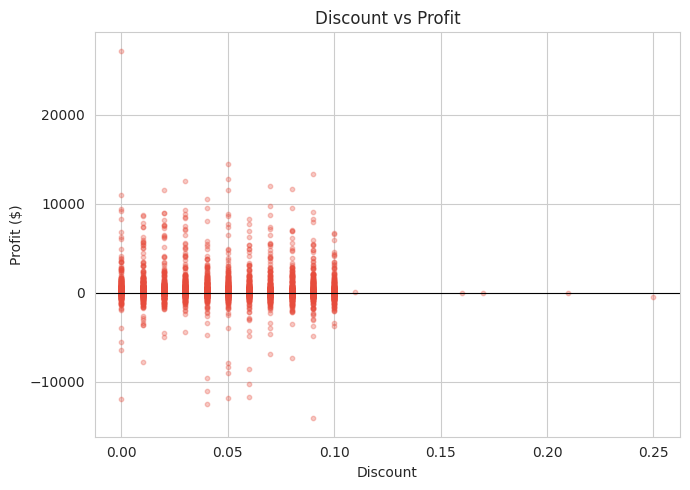

Loss-making orders: 4,264 out of 8,399 (50.8%)


In [7]:
plt.figure(figsize=(7,5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#e74c3c', s=10)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

loss_orders = (df['Profit']<0).sum()
print(f"Loss-making orders: {loss_orders:,} out of {len(df):,} ({loss_orders/len(df)*100:.1f}%)")

**Finding**: A striking **4,264 of 8,399 orders (50.8%)** are loss-making. Higher discounts (above ~30%) are heavily associated with negative profit, suggesting discounting policy may be eroding margins on a large share of orders.

## 7. Top Sub-Categories by Revenue

Product_Sub_Category
Office Machines                   2168697.14
Tables                            1896008.14
Telephones and Communication      1889313.80
Chairs & Chairmats                1761836.55
Copiers and Fax                   1130361.30
Storage & Organization            1070182.60
Binders and Binder Accessories    1022957.59
Bookcases                          822652.04
Computer Peripherals               795875.94
Appliances                         736991.54
Name: Sales, dtype: float64


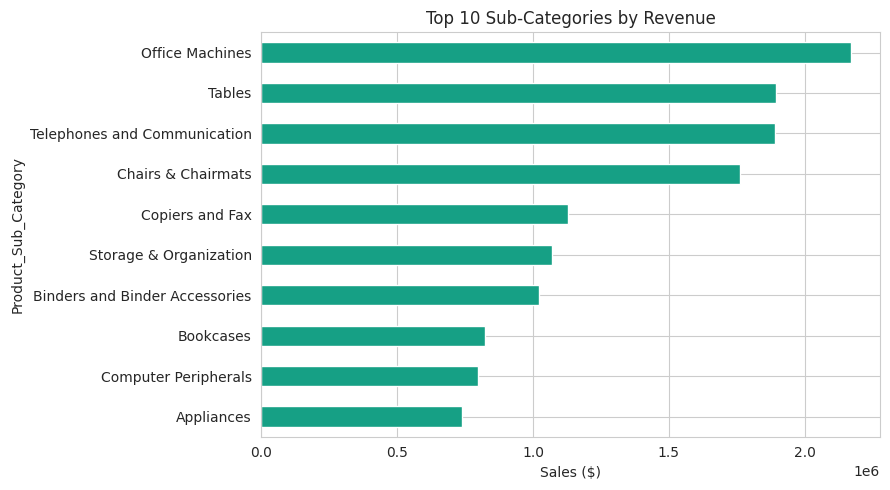

In [8]:
sub = df.groupby('Product_Sub_Category')['Sales'].sum().sort_values(ascending=False).head(10)
print(sub.round(2))

plt.figure(figsize=(9,5))
sub.plot(kind='barh', color='#16a085')
plt.title('Top 10 Sub-Categories by Revenue')
plt.xlabel('Sales ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Summary of Key Findings

1. Total revenue **$14.92M** across 8,399 orders, with a **10.20% overall profit margin**
2. **Technology** is the top revenue category (**$5.98M**), narrowly ahead of Furniture
3. Sales peaked in **2009** and haven't fully recovered by 2012
4. **Nunavut** region has a very thin margin (**2.44%**) compared to Northwest Territories (12.57%)
5. **50.8% of all orders are loss-making** — discounting appears to be a major driver of unprofitability

### Recommendations
- Review discounting policy, especially for discounts above 30%
- Investigate cost/pricing structure in the Nunavut region
- Focus retention and upsell efforts on Technology, the strongest category